<a href="https://colab.research.google.com/github/sonu786786/Responsible_AI/blob/main/Lab_10/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERT Probing Experiments

In [ ]:
# CELL 1: Install dependencies
!pip install transformers datasets scikit-learn matplotlib seaborn tqdm -q

In [ ]:
# CELL 2: Imports
import os
import re
import random
import urllib.request
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
from transformers import BertTokenizer, BertModel

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# CELL 3: Download raw data from SentEval GitHub
BASE_URL = (
    "https://raw.githubusercontent.com/facebookresearch/SentEval"
    "/main/data/probing/"
)

TASK_FILES = {
    "sentence_length": "sentence_length.txt",
    "bigram_shift":    "bigram_shift.txt",
    "subj_number":     "subj_number.txt",
}

os.makedirs("senteval_data", exist_ok=True)

for task, fname in TASK_FILES.items():
    dest = f"senteval_data/{fname}"
    if not os.path.exists(dest):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(BASE_URL + fname, dest)
        print(f"  Saved to {dest}")
    else:
        print(f"  {fname} already present.")

  Saved to senteval_data/sentence_length.txt
  Saved to senteval_data/bigram_shift.txt
  Saved to senteval_data/subj_number.txt


In [ ]:
# CELL 4: Parse and balance datasets  (50 000 samples, equal classes)
def parse_senteval_file(filepath):
    """
    SentEval probing files are TSV with columns:
        split  label  sentence
    Returns list of (label, sentence) tuples.
    """
    samples = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 3:
                continue
            # split = parts[0]  (tr / va / te) – we ignore original splits
            label    = parts[1]
            sentence = parts[2]
            samples.append((label, sentence))
    return samples


def balance_and_sample(samples, total=50_000, seed=SEED):
    """
    Group by label, then sample equal chunks so total ≈ `total`.
    Returns a list of (label, sentence) tuples.
    """
    by_label = defaultdict(list)
    for label, sent in samples:
        by_label[label].append((label, sent))

    labels     = sorted(by_label.keys())
    n_classes  = len(labels)
    per_class  = total // n_classes

    rng = random.Random(seed)
    balanced = []
    for lbl in labels:
        pool = by_label[lbl]
        if len(pool) >= per_class:
            balanced.extend(rng.sample(pool, per_class))
        else:
            # oversample with replacement if not enough data
            balanced.extend(rng.choices(pool, k=per_class))

    rng.shuffle(balanced)
    print(f"  Classes: {labels}")
    print(f"  Samples per class: {per_class}  |  Total: {len(balanced)}")
    return balanced


datasets = {}
for task, fname in TASK_FILES.items():
    print(f"\n── {task} ──")
    raw = parse_senteval_file(f"senteval_data/{fname}")
    print(f"  Raw samples: {len(raw)}")
    datasets[task] = balance_and_sample(raw, total=50_000)


── sentence_length ──
  Raw samples: 119988
  Classes: ['0', '1', '2', '3', '4', '5']
  Samples per class: 8333  |  Total: 49998

── bigram_shift ──
  Raw samples: 120000
  Classes: ['I', 'O']
  Samples per class: 25000  |  Total: 50000

── subj_number ──
  Raw samples: 120000
  Classes: ['NN', 'NNS']
  Samples per class: 25000  |  Total: 50000


In [ ]:
# CELL 5: Train / Test split (90:10, stratified)
splits = {}
for task, data in datasets.items():
    labels    = [d[0] for d in data]
    sentences = [d[1] for d in data]

    X_tr, X_te, y_tr, y_te = train_test_split(
        sentences, labels,
        test_size=0.10,
        random_state=SEED,
        stratify=labels,
    )
    splits[task] = {
        "train_sentences": X_tr, "train_labels": y_tr,
        "test_sentences":  X_te, "test_labels":  y_te,
    }
    print(f"{task}: train={len(X_tr)}  test={len(X_te)}")
    print(f"  Train class dist: {Counter(y_tr)}")
    print(f"  Test  class dist: {Counter(y_te)}")

sentence_length: train=44998  test=5000
  Train class dist: Counter({'1': 7500, '2': 7500, '0': 7500, '5': 7500, '4': 7499, '3': 7499})
  Test  class dist: Counter({'4': 834, '3': 834, '2': 833, '1': 833, '0': 833, '5': 833})
bigram_shift: train=45000  test=5000
  Train class dist: Counter({'I': 22500, 'O': 22500})
  Test  class dist: Counter({'O': 2500, 'I': 2500})
subj_number: train=45000  test=5000
  Train class dist: Counter({'NN': 22500, 'NNS': 22500})
  Test  class dist: Counter({'NNS': 2500, 'NN': 2500})


In [ ]:
# CELL 6: Load BERT-base (uncased) and build layer-wise extractor
MODEL_NAME = "bert-base-uncased"
tokenizer  = BertTokenizer.from_pretrained(MODEL_NAME)
bert_model = BertModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
bert_model = bert_model.to(DEVICE)
bert_model.eval()

NUM_LAYERS  = 12          # BERT-base has 12 transformer encoder layers
BATCH_SIZE  = 64          # tune down to 32 if OOM on T4
MAX_LENGTH  = 128

print(f"BERT loaded. Layers: {NUM_LAYERS} | Device: {DEVICE}")


def get_batch_representations(sentences, batch_size=BATCH_SIZE):
    """
    Returns a numpy array of shape (N, NUM_LAYERS, hidden_size).
    For each sentence we take the [CLS] token representation at each layer.
    """
    all_reps = []   # list of (N, 768) arrays, one per layer

    # We collect layer representations in layer-major order after all batches
    layer_buffers = [[] for _ in range(NUM_LAYERS)]

    for start in tqdm(range(0, len(sentences), batch_size), leave=False):
        batch = sentences[start: start + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = bert_model(**encoded)

        # outputs.hidden_states: tuple of (num_layers+1) tensors, each (B, T, H)
        # Index 0 = embedding layer, indices 1-12 = transformer layers
        hidden_states = outputs.hidden_states  # length 13

        for layer_idx in range(1, NUM_LAYERS + 1):        # layers 1 … 12
            cls_rep = hidden_states[layer_idx][:, 0, :]   # (B, H) CLS token
            layer_buffers[layer_idx - 1].append(cls_rep.cpu().numpy())

    # Concatenate across batches: each element is (N, H)
    layer_arrays = [np.concatenate(buf, axis=0) for buf in layer_buffers]
    # Stack to (N, NUM_LAYERS, H)
    reps = np.stack(layer_arrays, axis=1)
    return reps

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded. Layers: 12 | Device: cuda


In [ ]:
# CELL 7: Extract representations for all tasks
os.makedirs("representations", exist_ok=True)

task_reps = {}
for task in splits:
    cache_file = f"representations/{task}_reps.npz"
    if os.path.exists(cache_file):
        print(f"Loading cached representations for {task} ...")
        loaded = np.load(cache_file)
        task_reps[task] = {
            "train_reps":   loaded["train_reps"],
            "test_reps":    loaded["test_reps"],
            "train_labels": loaded["train_labels"],
            "test_labels":  loaded["test_labels"],
        }
    else:
        print(f"\nExtracting representations for {task} ...")
        tr_sents = splits[task]["train_sentences"]
        te_sents = splits[task]["test_sentences"]

        print("  → training sentences ...")
        tr_reps = get_batch_representations(tr_sents)  # (N_tr, 12, 768)
        print("  → test sentences ...")
        te_reps = get_batch_representations(te_sents)  # (N_te, 12, 768)

        np.savez_compressed(
            cache_file,
            train_reps=tr_reps,
            test_reps=te_reps,
            train_labels=np.array(splits[task]["train_labels"]),
            test_labels=np.array(splits[task]["test_labels"]),
        )
        task_reps[task] = {
            "train_reps":   tr_reps,
            "test_reps":    te_reps,
            "train_labels": np.array(splits[task]["train_labels"]),
            "test_labels":  np.array(splits[task]["test_labels"]),
        }
        print(f"  Saved to {cache_file}")

print("\nAll representations ready.")


Extracting representations for sentence_length ...
  → training sentences ...


  0%|          | 0/704 [00:00<?, ?it/s]

  → test sentences ...


  0%|          | 0/79 [00:00<?, ?it/s]

  Saved to representations/sentence_length_reps.npz

Extracting representations for bigram_shift ...
  → training sentences ...


...

  Saved to representations/bigram_shift_reps.npz

Extracting representations for subj_number ...
  → training sentences ...


  0%|          | 0/704 [00:00<?, ?it/s]

  → test sentences ...


  0%|          | 0/79 [00:00<?, ?it/s]

  Saved to representations/subj_number_reps.npz

All representations ready.


In [ ]:
# CELL 8: Train Logistic Regression probes (one per layer per task)
results = {}   # task -> list of accuracy scores (12 values)

for task in task_reps:
    print(f"\n{'='*55}")
    print(f"Task: {task}")
    print(f"{'='*55}")

    tr_reps   = task_reps[task]["train_reps"]    # (N_tr, 12, 768)
    te_reps   = task_reps[task]["test_reps"]     # (N_te, 12, 768)
    tr_labels = task_reps[task]["train_labels"]
    te_labels = task_reps[task]["test_labels"]

    le = LabelEncoder()
    y_train = le.fit_transform(tr_labels)
    y_test  = le.transform(te_labels)

    layer_accs = []
    for layer in range(NUM_LAYERS):
        X_train = tr_reps[:, layer, :]   # (N_tr, 768)
        X_test  = te_reps[:, layer, :]   # (N_te, 768)

        clf = LogisticRegression(
            max_iter=1000,
            solver="lbfgs",
            multi_class="auto",
            C=1.0,
            random_state=SEED,
            n_jobs=-1,
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc    = accuracy_score(y_test, y_pred) * 100.0   # percent
        layer_accs.append(acc)
        print(f"  Layer {layer+1:2d}:  Acc = {acc:.2f}%")

    results[task] = layer_accs
    best_layer = int(np.argmax(layer_accs)) + 1
    print(f"  ▶ Best layer: {best_layer}  ({max(layer_accs):.2f}%)")


Task: sentence_length
  Layer  1:  Acc = 89.26%
  Layer  2:  Acc = 92.06%
  Layer  3:  Acc = 92.64%
  Layer  4:  Acc = 91.70%
  Layer  5:  Acc = 88.82%
  Layer  6:  Acc = 85.78%
  Layer  7:  Acc = 81.66%
  Layer  8:  Acc = 79.92%
  Layer  9:  Acc = 76.04%
  Layer 10:  Acc = 73.76%
  Layer 11:  Acc = 69.52%
  Layer 12:  Acc = 65.18%
  ▶ Best layer: 3  (92.64%)

Task: bigram_shift
  Layer  1:  Acc = 51.10%
  Layer  2:  Acc = 58.00%
  Layer  3:  Acc = 65.12%
  Layer  4:  Acc = 75.06%
  Layer  5:  Acc = 81.40%
  Layer  6:  Acc = 82.28%
  Layer  7:  Acc = 82.66%
  Layer  8:  Acc = 83.48%
  Layer  9:  Acc = 86.48%
  Layer 10:  Acc = 86.10%
  Layer 11:  Acc = 86.60%
  Layer 12:  Acc = 86.92%
  ▶ Best layer: 12  (86.92%)

Task: subj_number
  Layer  1:  Acc = 80.12%
  Layer  2:  Acc = 84.10%
  Layer  3:  Acc = 84.34%
  Layer  4:  Acc = 85.20%
  Layer  5:  Acc = 87.56%
  Layer  6:  Acc = 89.74%
  Layer  7:  Acc = 88.12%
  Layer  8:  Acc = 87.94%
  Layer  9:  Acc = 87.82%
  Layer 10:  Acc = 87.2

In [ ]:
# CELL 9: Summary table
print("\n\n" + "="*65)
print(f"{'Layer':<8}", end="")
for task in results:
    print(f"  {task[:18]:<20}", end="")
print()
print("-"*65)
for layer in range(NUM_LAYERS):
    print(f"  {layer+1:<6}", end="")
    for task in results:
        print(f"  {results[task][layer]:>8.2f}%          ", end="")
    print()
print("="*65)



Layer     sentence_length       bigram_shift          subj_number         
-----------------------------------------------------------------
  1          89.26%               51.10%               80.12%          
  2          92.06%               58.00%               84.10%          
  3          92.64%               65.12%               84.34%          
  4          91.70%               75.06%               85.20%          
  5          88.82%               81.40%               87.56%          
  6          85.78%               82.28%               89.74%          
  7          81.66%               82.66%               88.12%          
  8          79.92%               83.48%               87.94%          
  9          76.04%               86.48%               87.82%          
  10         73.76%               86.10%               87.22%          
  11         69.52%               86.60%               86.08%          
  12         65.18%               86.92%               84.88%    

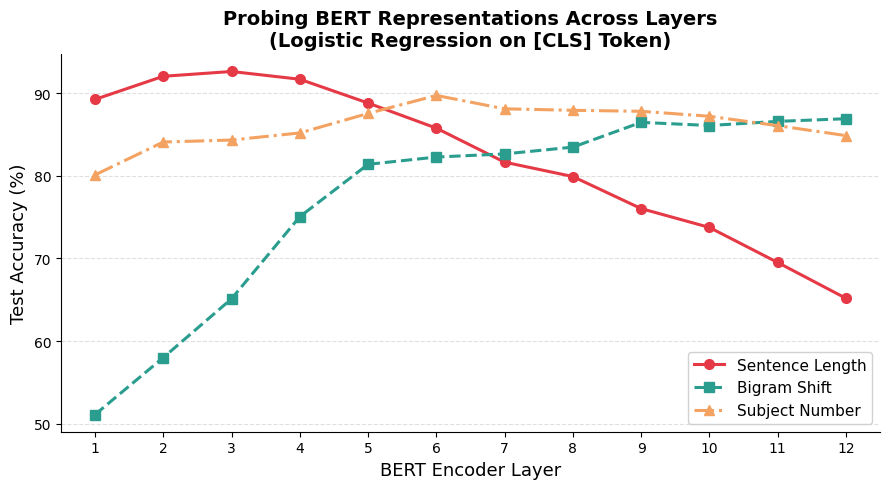

Plot saved as bert_probing_results.png


In [ ]:
# CELL 10: Plot — Layer vs Accuracy (publication-style)
TASK_LABELS = {
    "sentence_length": "Sentence Length",
    "bigram_shift":    "Bigram Shift",
    "subj_number":     "Subject Number",
}
COLORS    = ["#E63946", "#2A9D8F", "#F4A261"]
MARKERS   = ["o", "s", "^"]
LINESTYLES = ["-", "--", "-."]

fig, ax = plt.subplots(figsize=(9, 5))

for i, (task, accs) in enumerate(results.items()):
    layers = list(range(1, NUM_LAYERS + 1))
    ax.plot(
        layers, accs,
        color=COLORS[i],
        marker=MARKERS[i],
        linestyle=LINESTYLES[i],
        linewidth=2.2,
        markersize=7,
        label=TASK_LABELS.get(task, task),
    )

ax.set_xlabel("BERT Encoder Layer", fontsize=13)
ax.set_ylabel("Test Accuracy (%)", fontsize=13)
ax.set_title(
    "Probing BERT Representations Across Layers\n"
    "(Logistic Regression on [CLS] Token)",
    fontsize=14, fontweight="bold",
)
ax.set_xticks(range(1, NUM_LAYERS + 1))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=11, framealpha=0.9)
ax.set_xlim(0.5, NUM_LAYERS + 0.5)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("bert_probing_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as bert_probing_results.png")

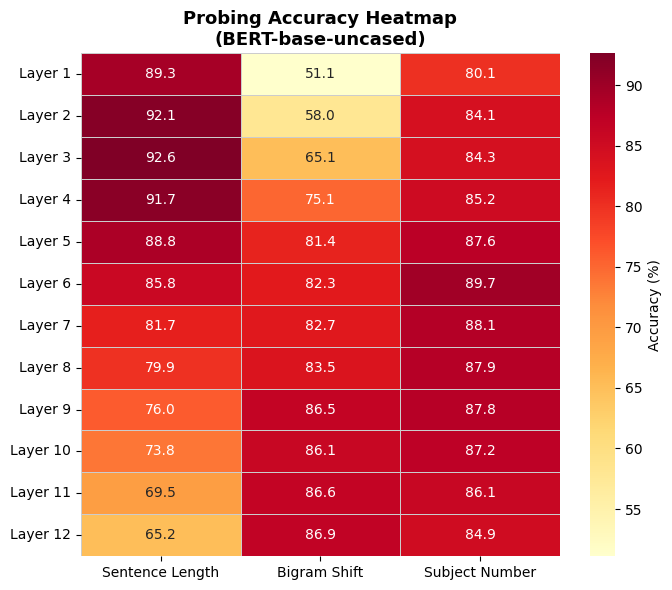

Heatmap saved as bert_probing_heatmap.png


In [ ]:
# CELL 11: Heatmap — tasks × layers
import pandas as pd

df = pd.DataFrame(
    {TASK_LABELS.get(t, t): v for t, v in results.items()},
    index=[f"Layer {i}" for i in range(1, NUM_LAYERS + 1)],
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    df, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, linecolor="#cccccc",
    cbar_kws={"label": "Accuracy (%)"},
    ax=ax,
)
ax.set_title("Probing Accuracy Heatmap\n(BERT-base-uncased)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("bert_probing_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved as bert_probing_heatmap.png")

In [ ]:
# CELL 12: Detailed classification report for best layer per task
print("\n\nDetailed reports for best layer per task:")
print("=" * 60)

for task in task_reps:
    tr_reps   = task_reps[task]["train_reps"]
    te_reps   = task_reps[task]["test_reps"]
    tr_labels = task_reps[task]["train_labels"]
    te_labels = task_reps[task]["test_labels"]

    le = LabelEncoder()
    y_train = le.fit_transform(tr_labels)
    y_test  = le.transform(te_labels)

    best_layer = int(np.argmax(results[task]))
    X_train = tr_reps[:, best_layer, :]
    X_test  = te_reps[:, best_layer, :]

    clf = LogisticRegression(
        max_iter=1000, solver="lbfgs",
        multi_class="auto", C=1.0, random_state=SEED, n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"\nTask : {TASK_LABELS.get(task, task)}")
    print(f"Best Layer : {best_layer + 1}   Accuracy: {results[task][best_layer]:.2f}%")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("-" * 60)

print("\nAll experiments complete!")



Detailed reports for best layer per task:

Task : Sentence Length
Best Layer : 3   Accuracy: 92.64%
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       833
           1       0.95      0.92      0.94       833
           2       0.91      0.91      0.91       833
           3       0.89      0.89      0.89       834
           4       0.89      0.89      0.89       834
           5       0.93      0.97      0.95       833

    accuracy                           0.93      5000
   macro avg       0.93      0.93      0.93      5000
weighted avg       0.93      0.93      0.93      5000

------------------------------------------------------------

Task : Bigram Shift
Best Layer : 12   Accuracy: 86.92%
              precision    recall  f1-score   support

           I       0.89      0.84      0.87      2500
           O       0.85      0.90      0.87      2500

    accuracy                           0.87      5000
   macro avg       0